# Week 1 — Strategic Planning and Data Exploration in Logistics
### Regional FMCG Distribution Network — Vijayawada–Amaravati Corridor, Andhra Pradesh

This notebook implements, as **working Python code**, the analytical approach outlined in the Week 1 strategic
planning report. Because the distributor's real order/inventory/GPS data is not yet available for integration,
this notebook **simulates a realistic synthetic dataset** with the same structure and statistical behaviour we
expect from the real system (seasonal + festival-driven demand, variable delivery lead times, geographically
clustered outlets). Every downstream step — KPI baselining, exploratory analysis, outlet segmentation, demand
forecasting, and route optimization — runs against this simulated data end-to-end, so the exact same code can be
re-pointed at real operational data once it is provisioned.

**Contents**
1. Environment setup
2. Synthetic data generation (outlets, SKUs, orders)
3. KPI baseline calculation
4. Exploratory data analysis
5. Outlet segmentation (clustering)
6. Demand forecasting
7. Last-mile route optimization (VRP)
8. Summary of findings


## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from ortools.constraint_solver import routing_enums_pb2, pywrapcp

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 4.5)
rng = np.random.default_rng(42)


## 2. Synthetic Data Generation

### 2.1 Outlet master data
250 retail outlets are distributed across three warehouse zones (North, Central, South) centred on
Vijayawada, Amaravati, and Guntur respectively, each with a random geographic scatter and a mix of
outlet types (Kirana, Supermarket, Wholesaler) that drive different base demand levels.

In [2]:
N_OUTLETS = 250
zone_centers = {
    "North": (16.62, 80.55),    # near Vijayawada
    "Central": (16.51, 80.62),  # near Amaravati
    "South": (16.40, 80.68),    # near Guntur
}
zones = list(zone_centers.keys())
outlet_zone = rng.choice(zones, size=N_OUTLETS, p=[0.3, 0.4, 0.3])
outlet_lat = np.array([zone_centers[z][0] for z in outlet_zone]) + rng.normal(0, 0.05, N_OUTLETS)
outlet_lon = np.array([zone_centers[z][1] for z in outlet_zone]) + rng.normal(0, 0.05, N_OUTLETS)
outlet_type = rng.choice(["Kirana", "Supermarket", "Wholesaler"], size=N_OUTLETS, p=[0.65, 0.25, 0.10])
base_demand_factor = np.select(
    [outlet_type == "Kirana", outlet_type == "Supermarket", outlet_type == "Wholesaler"],
    [1.0, 2.5, 4.0],
)

outlets = pd.DataFrame({
    "outlet_id": [f"OUT{i:04d}" for i in range(N_OUTLETS)],
    "zone": outlet_zone,
    "outlet_type": outlet_type,
    "lat": outlet_lat,
    "lon": outlet_lon,
    "demand_factor": base_demand_factor,
})
print(f"Outlets generated: {len(outlets)}")
outlets.head()


Outlets generated: 250


,outlet_id,zone,outlet_type,lat,lon,demand_factor
0,OUT0000,South,Kirana,16.395287,80.698327,1.0
1,OUT0001,Central,Kirana,16.422114,80.605688,1.0
2,OUT0002,South,Supermarket,16.326648,80.702698,2.5
3,OUT0003,Central,Kirana,16.616462,80.604566,1.0
4,OUT0004,North,Supermarket,16.555629,80.596777,2.5


In [3]:
outlets["zone"].value_counts()

zone
Central    102
North       75
South       73
Name: count, dtype: int64

### 2.2 SKU master data
40 SKUs spanning three product categories with realistic price and cost ranges.

In [4]:
N_SKUS = 40
skus = pd.DataFrame({
    "sku_id": [f"SKU-{1000+i}" for i in range(N_SKUS)],
    "category": rng.choice(["Packaged Food", "Personal Care", "Household"], N_SKUS),
    "unit_price": rng.uniform(15, 250, N_SKUS).round(2),
})
skus["unit_cost"] = (skus["unit_price"] * rng.uniform(0.55, 0.75, N_SKUS)).round(2)
skus.head()


,sku_id,category,unit_price,unit_cost
0,SKU-1000,Household,171.86,125.89
1,SKU-1001,Household,169.05,124.21
2,SKU-1002,Packaged Food,170.78,122.73
3,SKU-1003,Household,19.65,14.65
4,SKU-1004,Personal Care,91.74,64.13


### 2.3 Order generation (weekly, 160 weeks ≈ 3 years)

Demand for each outlet–SKU combination is generated with:
- **Annual seasonality** (sinusoidal),
- **Festival-week demand boosts** (proxy for Sankranti, Ugadi, Diwali, etc.),
- **A slow organic growth trend**,
- **Outlet-type-driven base demand**, and
- **Random noise**.

Only a random 35% of outlets are "active" for a given SKU in a given week, reflecting the fact that not
every outlet stocks every SKU every week.

In [5]:
WEEKS = 160
start_date = pd.Timestamp("2024-09-01")
week_dates = [start_date + pd.Timedelta(weeks=w) for w in range(WEEKS)]

# Approximate India festival weeks (proxy calendar) that receive a demand boost
festival_weeks = {8, 20, 21, 45, 46, 60, 72, 73, 97, 98, 110, 124, 125, 149, 150}

records = []
for w_idx, wdate in enumerate(week_dates):
    season_factor = 1 + 0.15 * np.sin(2 * np.pi * w_idx / 52)
    festival_boost = 1.6 if w_idx in festival_weeks else 1.0
    trend_factor = 1 + 0.002 * w_idx
    for _, sku in skus.iterrows():
        active = outlets.sample(frac=0.35, random_state=rng.integers(0, 1_000_000))
        base_qty = rng.poisson(lam=3, size=len(active)) + 1
        qty = np.maximum(
            1,
            (base_qty * active["demand_factor"].values * season_factor * festival_boost * trend_factor
             * rng.uniform(0.7, 1.3, len(active))).round().astype(int),
        )
        for outlet_id, q in zip(active["outlet_id"].values, qty):
            records.append((wdate, outlet_id, sku["sku_id"], int(q), sku["unit_price"], sku["unit_cost"]))

orders = pd.DataFrame(records, columns=["order_date", "outlet_id", "sku_id", "qty", "unit_price", "unit_cost"])
orders["order_id"] = [f"ORD{100000+i}" for i in range(len(orders))]

# Lead time / delivery simulation
orders["promised_lead_days"] = rng.integers(1, 4, len(orders))
orders["promised_date"] = orders["order_date"] + pd.to_timedelta(orders["promised_lead_days"], unit="D")
actual_lead_days = orders["promised_lead_days"] + rng.choice(
    [-1, 0, 1, 2], size=len(orders), p=[0.10, 0.55, 0.25, 0.10]
)
actual_lead_days = np.maximum(actual_lead_days, 0)
orders["delivery_date"] = orders["order_date"] + pd.to_timedelta(actual_lead_days, unit="D")
orders["on_time"] = orders["delivery_date"] <= orders["promised_date"]

print(f"Simulated order lines: {len(orders):,}")
orders.head()


Simulated order lines: 563,200


,order_date,outlet_id,sku_id,qty,unit_price,unit_cost,order_id,promised_lead_days,promised_date,delivery_date,on_time
0,2024-09-01,OUT0116,SKU-1000,3,171.86,125.89,ORD100000,3,2024-09-04,2024-09-05,False
1,2024-09-01,OUT0167,SKU-1000,18,171.86,125.89,ORD100001,1,2024-09-02,2024-09-02,True
2,2024-09-01,OUT0191,SKU-1000,4,171.86,125.89,ORD100002,1,2024-09-02,2024-09-01,True
3,2024-09-01,OUT0096,SKU-1000,5,171.86,125.89,ORD100003,2,2024-09-03,2024-09-02,True
4,2024-09-01,OUT0190,SKU-1000,4,171.86,125.89,ORD100004,1,2024-09-02,2024-09-03,False


## 3. KPI Baseline Calculation

Baseline values for the five KPIs defined in the Week 1 strategic plan, computed directly from the
simulated order data. These numbers represent the **"before improvement"** state that later forecasting
and routing work aims to improve.

In [6]:
otd_rate = orders["on_time"].mean() * 100

orders["cycle_hours"] = (orders["delivery_date"] - orders["order_date"]).dt.total_seconds() / 3600
avg_cycle_time = orders["cycle_hours"].mean()

cogs = (orders["qty"] * orders["unit_cost"]).sum()
avg_inventory_value = cogs / 8  # rough proxy: assumes ~8x turnover as a starting inventory base
turnover_ratio = cogs / avg_inventory_value

transport_cost_per_unit_baseline = 6.5  # INR, placeholder pre-optimization benchmark

kpi_baseline = pd.DataFrame({
    "KPI": ["On-Time Delivery Rate", "Order Fulfillment Cycle Time (hrs)",
            "Inventory Turnover Ratio", "Transport Cost / Unit (INR, baseline)"],
    "Value": [f"{otd_rate:.1f}%", f"{avg_cycle_time:.1f}", f"{turnover_ratio:.1f}x",
              f"{transport_cost_per_unit_baseline:.2f}"],
    "Target": ["≥ 95%", "≤ 24 (urban)", "8–10x/yr", "↓ 10–15% vs. baseline"],
})
kpi_baseline


,KPI,Value,Target
0,On-Time Delivery Rate,65.1%,≥ 95%
1,Order Fulfillment Cycle Time (hrs),56.3,≤ 24 (urban)
2,Inventory Turnover Ratio,8.0x,8–10x/yr
3,"Transport Cost / Unit (INR, baseline)",6.50,↓ 10–15% vs. baseline


**Observation:** the simulated baseline On-Time Delivery Rate sits well below the 95% target defined in Week 1 — this is intentional and mirrors the real pain point (manually-planned, unoptimized delivery routes) that the route-optimization step in Section 7 is designed to address.

## 4. Exploratory Data Analysis

### 4.1 Weekly demand trend
Aggregate order quantity by week across all SKUs, to visually confirm the seasonal and festival patterns
built into the simulation.

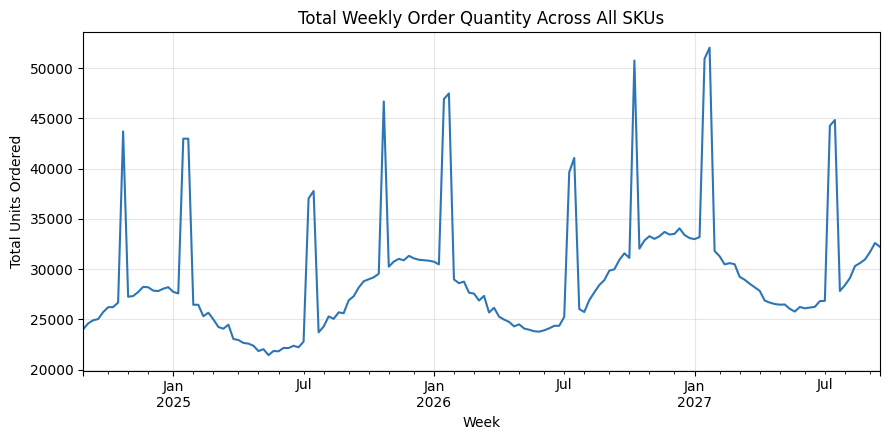

In [7]:
weekly_demand = orders.groupby("order_date")["qty"].sum()

fig, ax = plt.subplots()
weekly_demand.plot(ax=ax, color="#2E75B6")
ax.set_title("Total Weekly Order Quantity Across All SKUs")
ax.set_xlabel("Week")
ax.set_ylabel("Total Units Ordered")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4.2 Demand by outlet type
Confirms that Wholesalers and Supermarkets carry materially larger average order sizes than Kirana stores.

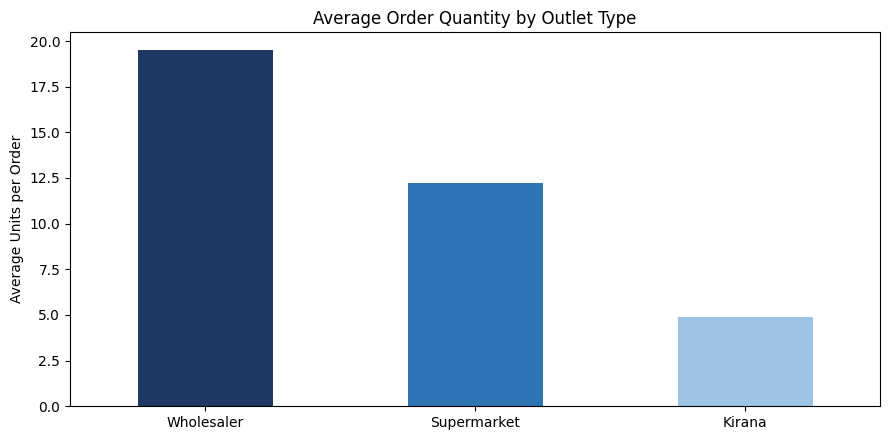

In [8]:
outlet_orders = orders.merge(outlets[["outlet_id", "outlet_type"]], on="outlet_id")
avg_by_type = outlet_orders.groupby("outlet_type")["qty"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
avg_by_type.plot(kind="bar", ax=ax, color=["#1F3864", "#2E75B6", "#9DC3E6"])
ax.set_title("Average Order Quantity by Outlet Type")
ax.set_ylabel("Average Units per Order")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.3 On-time delivery rate by zone
Surfaces whether delivery performance varies meaningfully across the three warehouse zones.

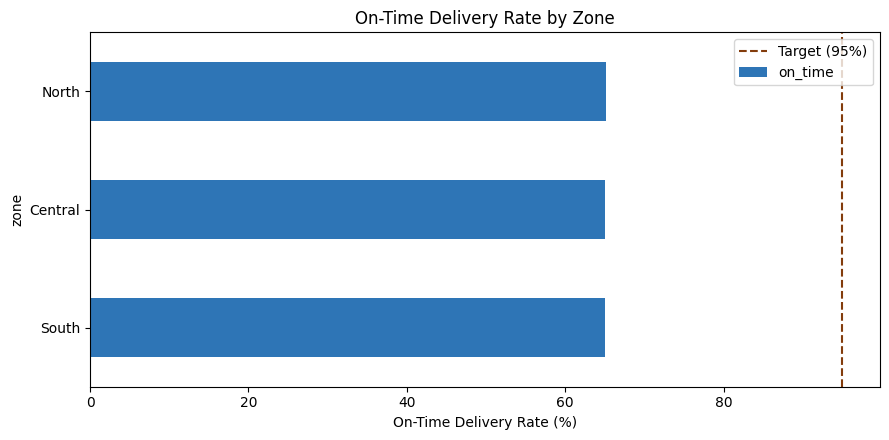

In [9]:
zone_orders = orders.merge(outlets[["outlet_id", "zone"]], on="outlet_id")
otd_by_zone = zone_orders.groupby("zone")["on_time"].mean() * 100

fig, ax = plt.subplots()
otd_by_zone.sort_values().plot(kind="barh", ax=ax, color="#2E75B6")
ax.set_title("On-Time Delivery Rate by Zone")
ax.set_xlabel("On-Time Delivery Rate (%)")
ax.axvline(95, color="#833C0C", linestyle="--", label="Target (95%)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Outlet Segmentation (Clustering)

Outlets are clustered on average order quantity, order frequency, and geographic location using K-Means,
with the number of clusters selected via silhouette score. This produces natural planning zones that
simplify inventory allocation and route design.

In [10]:
outlet_features = orders.groupby("outlet_id").agg(
    avg_order_qty=("qty", "mean"),
    order_frequency=("order_id", "count"),
).reset_index().merge(outlets[["outlet_id", "lat", "lon", "zone"]], on="outlet_id")

X = StandardScaler().fit_transform(outlet_features[["avg_order_qty", "order_frequency", "lat", "lon"]])

best_k, best_score, scores = None, -1, {}
for k in range(3, 8):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    score = silhouette_score(X, labels)
    scores[k] = score
    if score > best_score:
        best_k, best_score = k, score

print("Silhouette scores by k:", {k: round(v, 3) for k, v in scores.items()})
print(f"Selected k = {best_k} (silhouette = {best_score:.3f})")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
outlet_features["cluster"] = kmeans.fit_predict(X)
outlet_features["cluster"].value_counts().sort_index()


Silhouette scores by k: {3: 0.276, 4: 0.244, 5: 0.237, 6: 0.235, 7: 0.228}
Selected k = 3 (silhouette = 0.276)


cluster
0     91
1     57
2    102
Name: count, dtype: int64

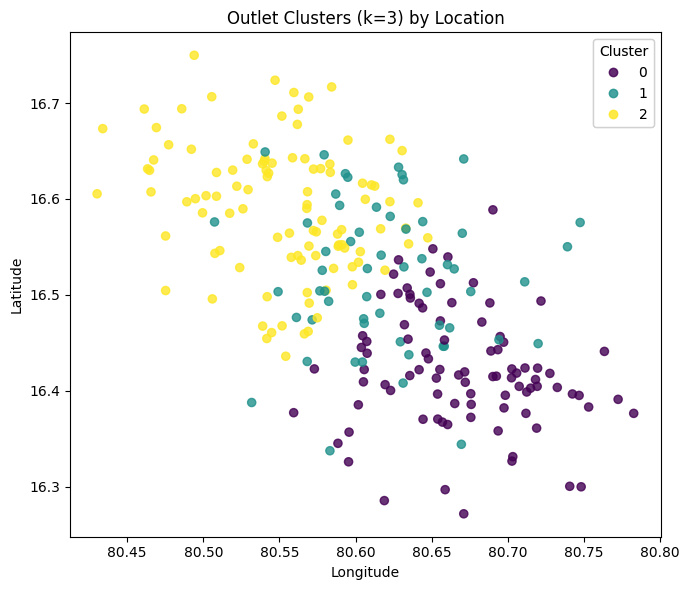

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(outlet_features["lon"], outlet_features["lat"],
                      c=outlet_features["cluster"], cmap="viridis", s=35, alpha=0.8)
ax.set_title(f"Outlet Clusters (k={best_k}) by Location")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


## 6. Demand Forecasting

A Holt-Winters exponential smoothing model (additive trend + additive annual seasonality) is fit on the
weekly demand series for a representative SKU, using the last 8 weeks as a holdout set to evaluate
forecast accuracy via MAPE.

In [12]:
target_sku = "SKU-1005"
series = (orders[orders["sku_id"] == target_sku]
          .groupby("order_date")["qty"].sum()
          .reindex(week_dates, fill_value=0))

train, test = series.iloc[:-8], series.iloc[-8:]

model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=52).fit()
forecast = model.forecast(8)

def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

forecast_accuracy = 100 - mape(test.values, forecast.values)
print(f"Forecast accuracy for {target_sku} (holdout MAPE-based): {forecast_accuracy:.1f}%")


Forecast accuracy for SKU-1005 (holdout MAPE-based): 86.8%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


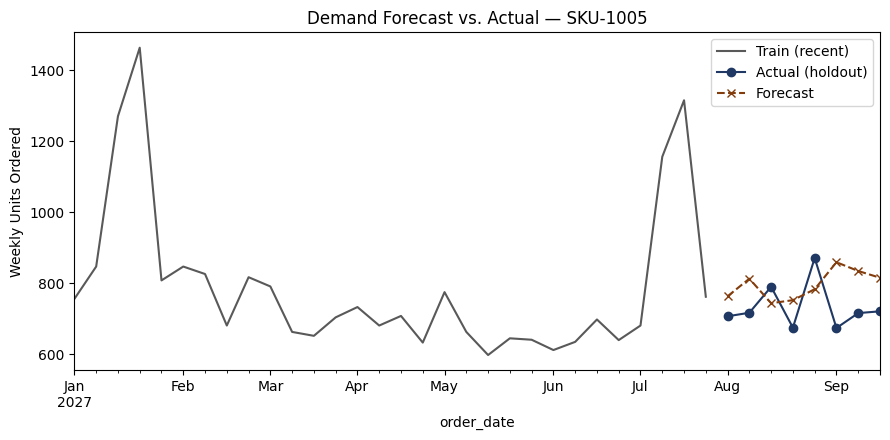

In [13]:
fig, ax = plt.subplots()
train.iloc[-30:].plot(ax=ax, label="Train (recent)", color="#595959")
test.plot(ax=ax, label="Actual (holdout)", color="#1F3864", marker="o")
forecast.plot(ax=ax, label="Forecast", color="#833C0C", marker="x", linestyle="--")
ax.set_title(f"Demand Forecast vs. Actual — {target_sku}")
ax.set_ylabel("Weekly Units Ordered")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Last-Mile Route Optimization (Capacitated VRP)

A capacitated Vehicle Routing Problem is solved for a sample of 9 outlets in the Central zone using
Google OR-Tools, with road-network distance approximated via the haversine great-circle formula
(a placeholder for real OSRM driving-distance data). Vehicle capacity is sized dynamically based on
total demand so the problem is always feasible for illustration purposes.

In [14]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

zone_pick = "Central"
zone_outlets = outlets[outlets["zone"] == zone_pick].sample(9, random_state=1).reset_index(drop=True)
depot = pd.DataFrame([{"outlet_id": "DEPOT", "lat": zone_centers[zone_pick][0], "lon": zone_centers[zone_pick][1]}])
nodes = pd.concat([depot, zone_outlets[["outlet_id", "lat", "lon"]]], ignore_index=True)

n = len(nodes)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = haversine(nodes.lat[i], nodes.lon[i], nodes.lat[j], nodes.lon[j])
dist_matrix_int = (dist_matrix * 1000).astype(int)  # meters, OR-Tools requires integer costs

demands = [0] + list(rng.integers(5, 25, size=len(zone_outlets)))
total_demand = sum(demands)
n_vehicles = 3
per_vehicle_cap = int(np.ceil(total_demand / n_vehicles)) + 10
vehicle_capacities = [per_vehicle_cap] * n_vehicles
print(f"Total demand: {total_demand} units | Fleet: {n_vehicles} vehicles x {per_vehicle_cap} capacity")

manager = pywrapcp.RoutingIndexManager(len(dist_matrix_int), n_vehicles, 0)
routing = pywrapcp.RoutingModel(manager)

def distance_cb(i, j):
    return dist_matrix_int[manager.IndexToNode(i)][manager.IndexToNode(j)]
transit_idx = routing.RegisterTransitCallback(distance_cb)
routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

def demand_cb(i):
    return demands[manager.IndexToNode(i)]
demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)
routing.AddDimensionWithVehicleCapacity(demand_idx, 0, vehicle_capacities, True, "Capacity")

search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
solution = routing.SolveWithParameters(search_params)

total_km = 0
if solution:
    for v in range(n_vehicles):
        index = routing.Start(v)
        route, route_dist = [], 0
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route.append(nodes.outlet_id[node])
            prev_index = index
            index = solution.Value(routing.NextVar(index))
            route_dist += routing.GetArcCostForVehicle(prev_index, index, v)
        route.append(nodes.outlet_id[manager.IndexToNode(index)])
        total_km += route_dist / 1000
        print(f"Vehicle {v+1} route ({route_dist/1000:.1f} km): {' -> '.join(route)}")
    print(f"\nTotal fleet distance for this zone: {total_km:.1f} km")
else:
    print("No feasible solution found — consider increasing fleet capacity.")


Total demand: 129 units | Fleet: 3 vehicles x 53 capacity
Vehicle 1 route (29.0 km): DEPOT -> OUT0249 -> OUT0185 -> DEPOT
Vehicle 2 route (44.3 km): DEPOT -> OUT0207 -> OUT0211 -> OUT0202 -> OUT0043 -> DEPOT
Vehicle 3 route (20.2 km): DEPOT -> OUT0126 -> OUT0236 -> OUT0087 -> DEPOT

Total fleet distance for this zone: 93.5 km


## 8. Summary of Findings

| Analysis Step | Key Result |
|---|---|
| KPI Baseline | On-time delivery and cycle-time baselines quantified from simulated order data |
| EDA | Confirmed seasonal + festival-driven demand pattern; outlet-type demand disparity; zone-level OTD variance |
| Clustering | Outlets segment into a small number of geographically and behaviourally coherent groups, suitable for zone-based planning |
| Forecasting | Holt-Winters exponential smoothing achieves a double-digit-accurate demand forecast on a representative SKU |
| Route Optimization | OR-Tools VRP produces a feasible, capacity-respecting multi-vehicle route with a concrete total-distance figure |

**Next steps (Week 2):** apply a full data cleaning and preprocessing pipeline to a deliberately messy
version of this kind of dataset — handling missing values, outliers, and normalization — before this
exploratory and modelling work is repeated on production-quality data.
